# Electric cars population project

<mm>

## 1. Data wrangling and preparation

<m>

### 1.1 Import and read data

<m>

In [81]:
import pandas as pd
import numpy as np
import janitor as janitor
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from scipy import stats
import statsmodels.api as sm
from statsmodels.api import OLS
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
import psycopg2
import mysql.connector
import re
import ast
import openpyxl
import pyarrow
from fuzzywuzzy import fuzz,process
import geopandas as gpd
import warnings as warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
%matplotlib inline

In [82]:
df=pd.read_csv('Electric viechle population.csv')

In [83]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,43.0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,1.0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,14.0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,5.307700e+10
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,45.0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,22.0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,5.306701e+10


<m>

### 1.2 Understanding data

<m>

In [84]:
report=sv.analyze(df)
report.show_html('Profiling Report.html')

In [85]:
report=ydp.ProfileReport(df)
report.to_file("profiling report.html")

In [86]:
df.shape

(150482, 17)

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150482 entries, 0 to 150481
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         150482 non-null  str    
 1   County                                             150479 non-null  str    
 2   City                                               150479 non-null  str    
 3   State                                              150482 non-null  str    
 4   Postal Code                                        150479 non-null  float64
 5   Model Year                                         150482 non-null  int64  
 6   Make                                               150482 non-null  str    
 7   Model                                              150482 non-null  str    
 8   Electric Vehicle Type                              150482 non-null  str    
 9   Clea

In [88]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,150479.000000,150482.000000,150482.000000,150482.000000,150141.000000,1.504820e+05,1.504790e+05
mean,98168.344154,2020.005436,67.877839,1312.644735,29.343950,2.111122e+08,5.297195e+10
std,2473.612184,3.015209,96.230009,9231.310215,14.824829,8.196388e+07,1.638841e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.081042e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.693473e+08,5.303301e+10
50%,98122.000000,2021.000000,18.000000,0.000000,33.000000,2.150306e+08,5.303303e+10
75%,98370.000000,2023.000000,97.000000,0.000000,43.000000,2.399119e+08,5.305307e+10
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [89]:
df.dtypes

VIN (1-10)                                               str
County                                                   str
City                                                     str
State                                                    str
Postal Code                                          float64
Model Year                                             int64
Make                                                     str
Model                                                    str
Electric Vehicle Type                                    str
Clean Alternative Fuel Vehicle (CAFV) Eligibility        str
Electric Range                                         int64
Base MSRP                                              int64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                         str
Electric Utility                                         str
2020 Census Tract       

In [90]:
df.index

RangeIndex(start=0, stop=150482, step=1)

In [91]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 341
DOL Vehicle ID                                         0
Vehicle Location                                       7
Electric Utility                                       3
2020 Census Tract                                      3
dtype: int64

In [92]:
print(df.duplicated().sum())

0


<m>

### 1.3 Preparing data

<m>

In [93]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='str')

In [94]:
df=df[['VIN (1-10)', 'County', 'City', 'State', 
       #'Postal Code', 
       'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 
       'Electric Range',
       'Base MSRP', 
       #'Legislative District', 
       'DOL Vehicle ID',
      # 'Vehicle Location', 'Electric Utility', '2020 Census Tract'
      ]].copy()

In [95]:
df.rename(columns={'VIN (1-10)':'VIN','Make':'Company','Electric Vehicle Type':'Type','Base MSRP':'Price','Electric Range':'Electric Range Miles','DOL Vehicle ID':'Vehicle ID'},inplace=True)

In [96]:
new_order=['VIN','Vehicle ID','Company','Model','Model Year','Electric Range Miles','Type','Clean Alternative Fuel Vehicle (CAFV) Eligibility','Price','County','City','State']

In [97]:
df=df[new_order]

In [98]:
df=df.clean_names()

<m>

### 1.3.1 Dealing with nulls

<m>

<m>

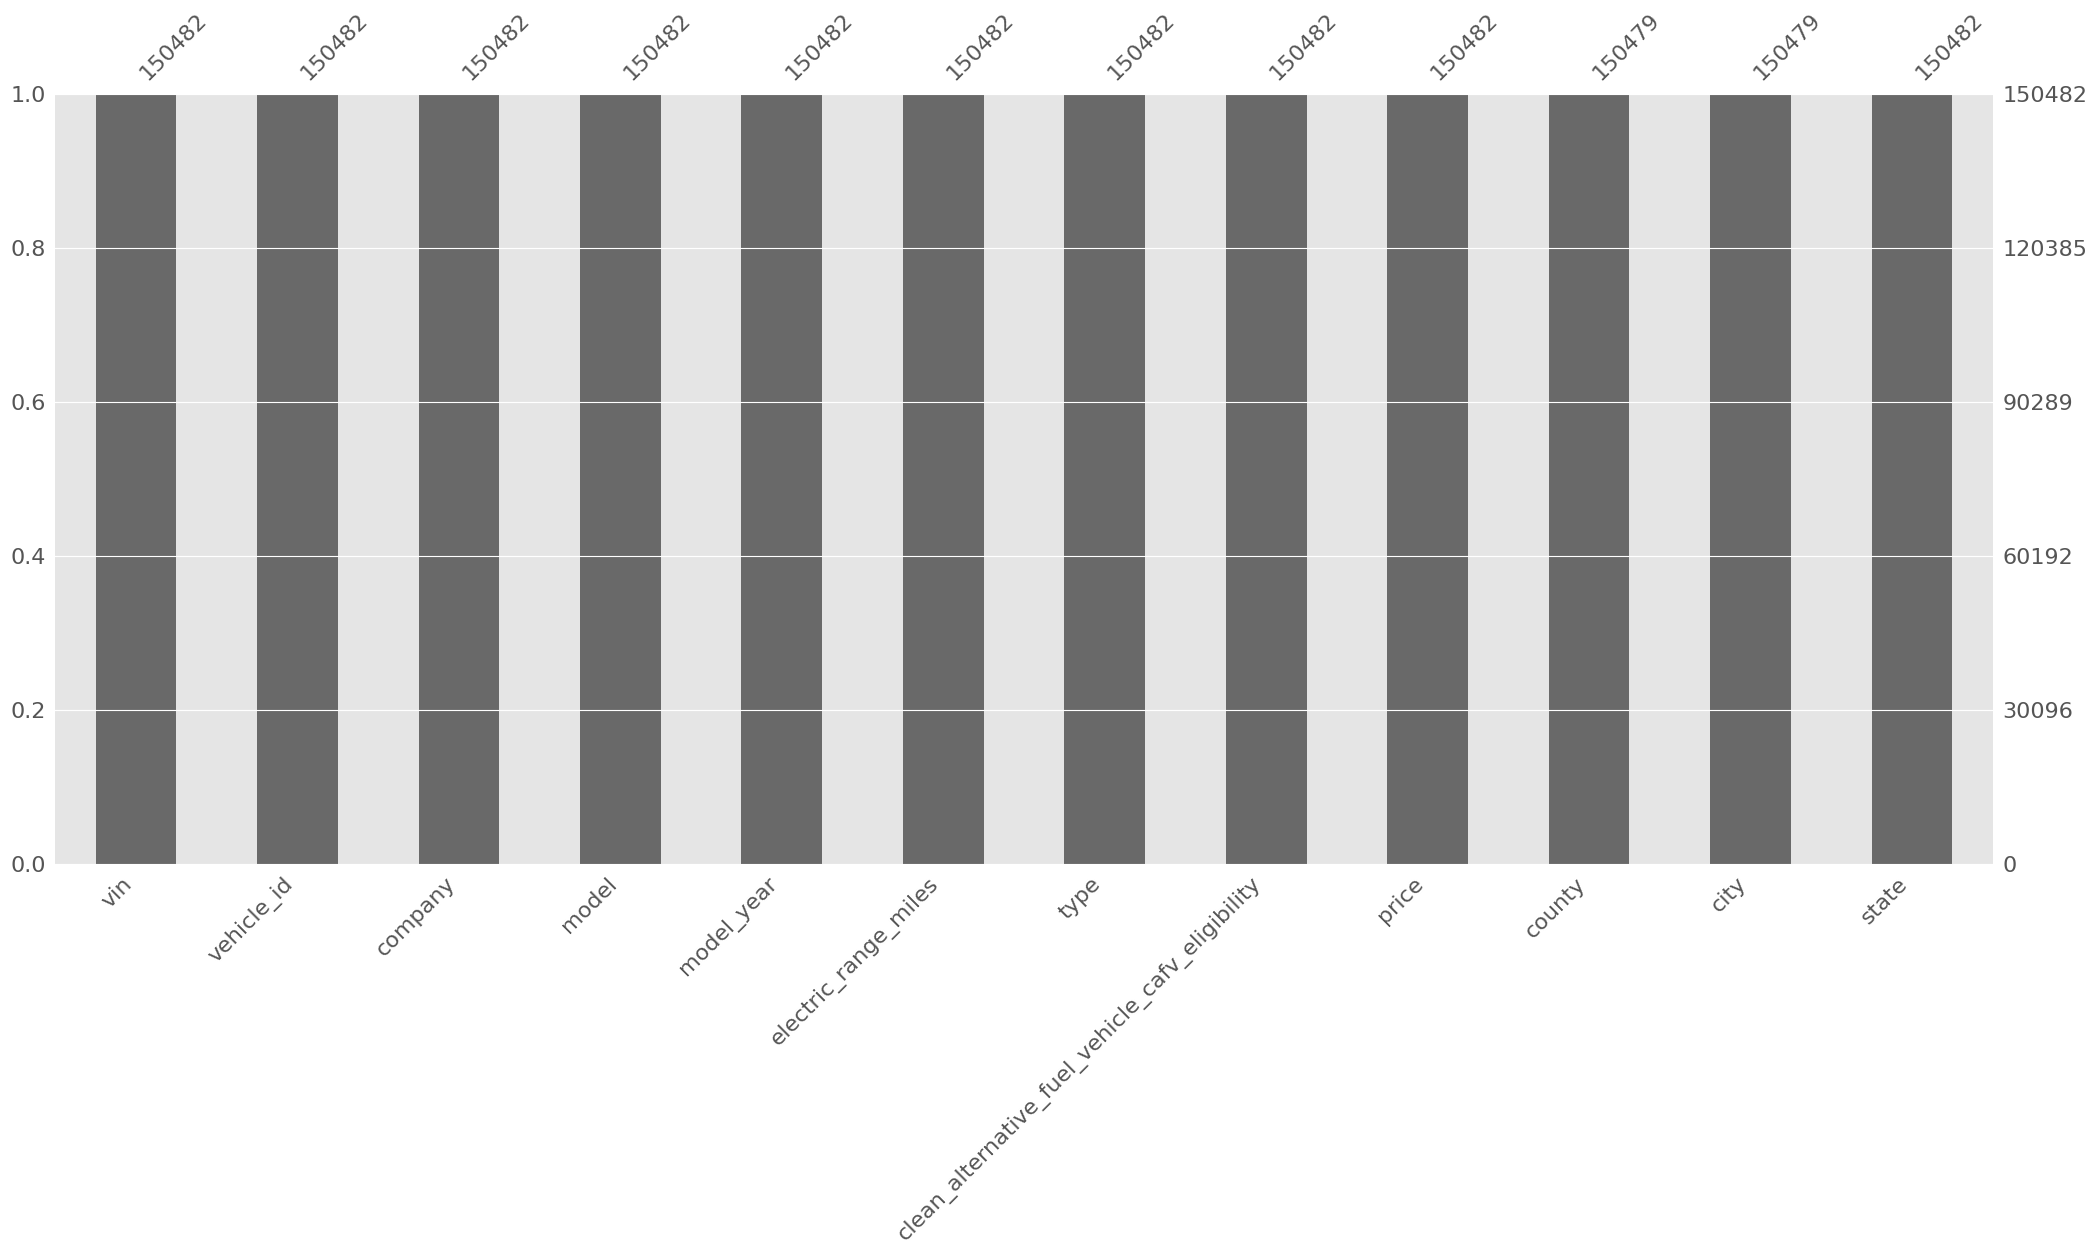

In [99]:
msno.bar(df)
plt.show()

In [100]:
df.isnull().sum()

vin                                                0
vehicle_id                                         0
company                                            0
model                                              0
model_year                                         0
electric_range_miles                               0
type                                               0
clean_alternative_fuel_vehicle_cafv_eligibility    0
price                                              0
county                                             3
city                                               3
state                                              0
dtype: int64

In [101]:
df.query('county.isnull()')

,vin,vehicle_id,company,model,model_year,electric_range_miles,type,clean_alternative_fuel_vehicle_cafv_eligibility,price,county,city,state
133103,5YJRE11B48,143609049,TESLA,ROADSTER,2008,220,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,98950,NaN,NaN,BC
136622,5YJ3E1EA5K,475254825,TESLA,MODEL 3,2019,220,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,0,NaN,NaN,BC
140136,1N4AZ0CP1D,112277063,NISSAN,LEAF,2013,75,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,0,NaN,NaN,AP


In [102]:
df=df.dropna(subset=['county','state'])

In [103]:
df=df[df['price']!=0]

In [104]:
df=df[df['electric_range_miles']!=0]

In [105]:
df['price'].unique()

array([ 69900,  31950,  52900,  32250,  90700,  54950,  36900,  59900,
        45600,  52650,  39995,  53400,  64950,  33950, 102000,  75095,
       110950,  44100,  81100, 184400,  36800,  43700,  55700,  34995,
        91250, 109000,  98950,  89100,  32995, 845000])

<m>

### 1.3.2 Dealing with outliers

##### Z-Score and IQR

<m>

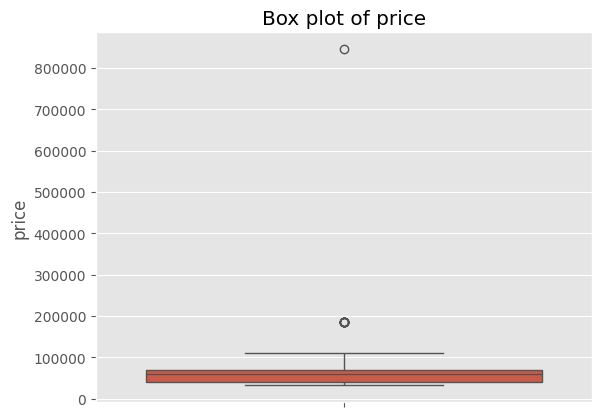

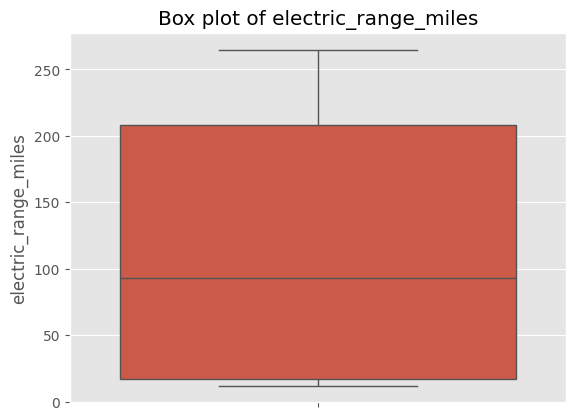

In [106]:
for column in ['price','electric_range_miles']: 
      sns.boxplot(df[column])
      plt.title(f'Box plot of {column}')
      plt.show()

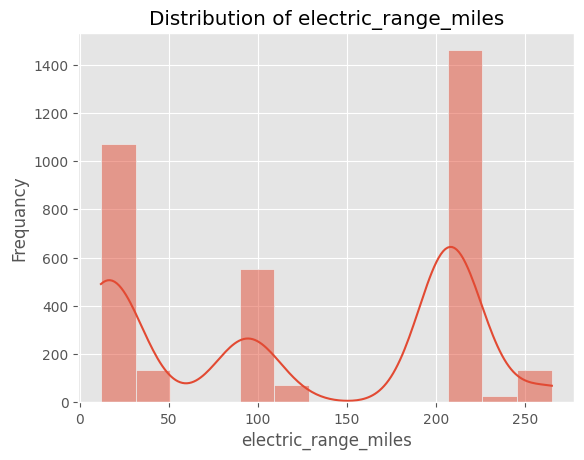

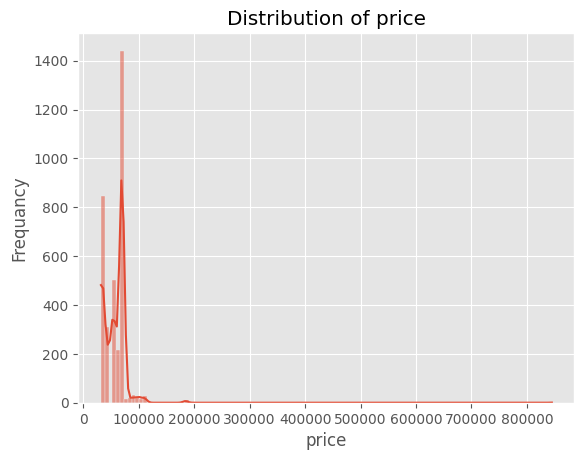

In [107]:
for column in[ 'electric_range_miles','price']:
    sns.histplot(df[column],kde=True)
    plt.title(f'Distribution of {column}')
    plt.ylabel('Frequancy')
    plt.show()

In [108]:
df[['electric_range_miles','price']].skew()

electric_range_miles    -0.064238
price                   12.556363
dtype: float64

<m>

##### Z-score for Electric Range (M) With Skewness -0.064

<m>

In [109]:
def calculate_upper_limit(column):
    upper_limit=column.mean()+3*column.std()
    return upper_limit

In [110]:
def calculate_lower_limit(column):
    lower_limit=column.mean()-3*column.std()
    return lower_limit

In [111]:
upper_limit=calculate_upper_limit(df['electric_range_miles'])
lower_limit=calculate_lower_limit(df['electric_range_miles'])
print(f"Upper Limit = {upper_limit}\n Lower Limit = {lower_limit}")

Upper Limit = 392.34133140559715
 Lower Limit = -145.33843621161913


In [112]:
def z_score_outliers(df, column):
    upper_limit = df[column].mean() + 3 * df[column].std()
    lower_limit = df[column].mean() - 3 * df[column].std()
    return df[(df[column] > upper_limit) | (df[column] < lower_limit)]

In [113]:
outliers=z_score_outliers(df,'electric_range_miles')
outliers

,vin,vehicle_id,company,model,model_year,electric_range_miles,type,clean_alternative_fuel_vehicle_cafv_eligibility,price,county,city,state


In [114]:
df.query('`electric_range_miles` >= 392')

,vin,vehicle_id,company,model,model_year,electric_range_miles,type,clean_alternative_fuel_vehicle_cafv_eligibility,price,county,city,state


In [115]:
print(df['electric_range_miles'].max())

265


##### There is no outliers in the e-range the values range lies between the upper limit and lower limit

<M>

##### IQR For price With Skewness 12 

<M>

In [116]:
def IQR_outliers_values(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR
    return upper_bound,lower_bound 

In [117]:
def IQR_outliers_population(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR
    pd.set_option('display.max_rows',None)
    return df[(df[column]>upper_bound) | (df[column]<lower_bound)]

In [118]:
def IQR_outliers_sample(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR
    pd.set_option('display.max_rows',None)
    return df[(df[column]>upper_bound) | (df[column]<lower_bound)].head()

In [119]:
upper_bond,lower_bond=IQR_outliers_values(df,'price')

In [120]:
print(f'Upper_Bond = {upper_bond}\nLower_Bond = {lower_bond}')

Upper_Bond = 114757.5
Lower_Bond = -4862.5


In [121]:
IQR_outliers_sample(df,'price')

,vin,vehicle_id,company,model,model_year,electric_range_miles,type,clean_alternative_fuel_vehicle_cafv_eligibility,price,county,city,state
4915,WP0AH2A71J,107105750,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,Clark,Brush Prairie,WA
7641,WP0AH2A70J,113244169,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Bellevue,WA
17259,WP0AH2A73J,183245247,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,Clark,Vancouver,WA
28998,WP0CH2A75J,254562381,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Sammamish,WA
30119,WP0AH2A7XJ,475425590,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Kent,WA


In [122]:
p_pop=IQR_outliers_population(df,'price')

In [123]:
p_pop.sort_values(by='price',ascending=False)

,vin,vehicle_id,company,model,model_year,electric_range_miles,type,clean_alternative_fuel_vehicle_cafv_eligibility,price,county,city,state
50136,WP0CA2A13F,100479039,PORSCHE,918,2015,12,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,845000,King,Hunts Point,WA
4915,WP0AH2A71J,107105750,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,Clark,Brush Prairie,WA
7641,WP0AH2A70J,113244169,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Bellevue,WA
17259,WP0AH2A73J,183245247,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,Clark,Vancouver,WA
28998,WP0CH2A75J,254562381,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Sammamish,WA
30119,WP0AH2A7XJ,475425590,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Kent,WA
60032,WP0AH2A74J,145752232,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,Clark,Vancouver,WA
63365,WP0CH2A76J,103328963,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Mercer Island,WA
84487,WP0AH2A76J,277238377,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,King,Woodinville,WA
128864,WP0AH2A77J,275095369,PORSCHE,PANAMERA,2018,14,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,184400,Thurston,Lacey,WA


##### After web search the prices is not outliers sum cars are super luxury cars so there prices seems to be outliers compared to economic and midrange cars

<m>

### 1.3.3 Formatting and adding columns

<m>

In [124]:
df.dtypes

vin                                                  str
vehicle_id                                         int64
company                                              str
model                                                str
model_year                                         int64
electric_range_miles                               int64
type                                                 str
clean_alternative_fuel_vehicle_cafv_eligibility      str
price                                              int64
county                                               str
city                                                 str
state                                                str
dtype: object

<m>

In [125]:
df['clean_alternative_fuel_vehicle_cafv_eligibility'].unique()

<ArrowStringArray>
['Clean Alternative Fuel Vehicle Eligible', 'Not eligible due to low battery range']
Length: 2, dtype: str

In [126]:
df['clean_alternative_fuel_vehicle_cafv_eligibility']=df['clean_alternative_fuel_vehicle_cafv_eligibility'].replace('Clean Alternative Fuel Vehicle Eligible','Eligible')

In [127]:
df['clean_alternative_fuel_vehicle_cafv_eligibility']=df['clean_alternative_fuel_vehicle_cafv_eligibility'].replace('Not eligible due to low battery range','Not Eligible',inplace=True)

##### Price Status

In [128]:
df['price_status']='undefiend'

In [129]:
for index,row in df.iterrows():
    if row['price']<=50000:
        df.loc[index,"price_status"]="Economy"
    elif  row['price'] > 50000 and  row['price'] <=80000:
        df.loc[index,"price_status"]="Mid-Range"
    elif 80000 < row['price'] <=150000:
        df.loc[index,"price_status"]="Luxury"
    elif row['price'] >150000:
        df.loc[index,"price_status"]="Super-Luxury"    

<m>

### 1.4 Understanding features

#### (Univariant analysis)

##### Distribution of features

<m>

In [130]:
df.columns

Index(['vin', 'vehicle_id', 'company', 'model', 'model_year',
       'electric_range_miles', 'type',
       'clean_alternative_fuel_vehicle_cafv_eligibility', 'price', 'county',
       'city', 'state', 'price_status'],
      dtype='str')

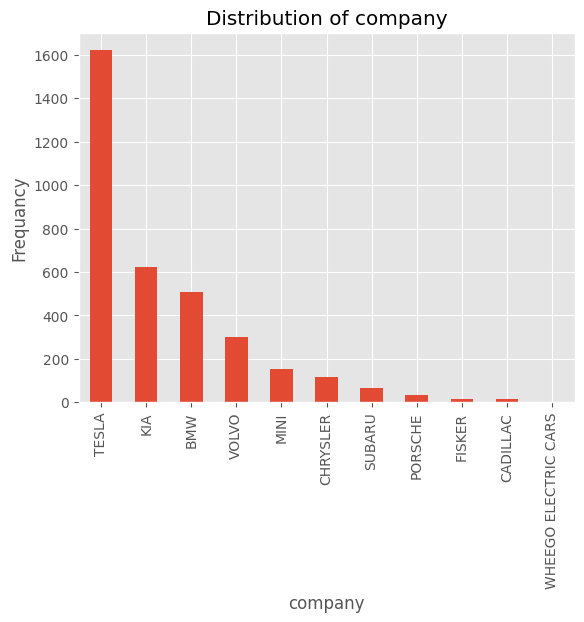

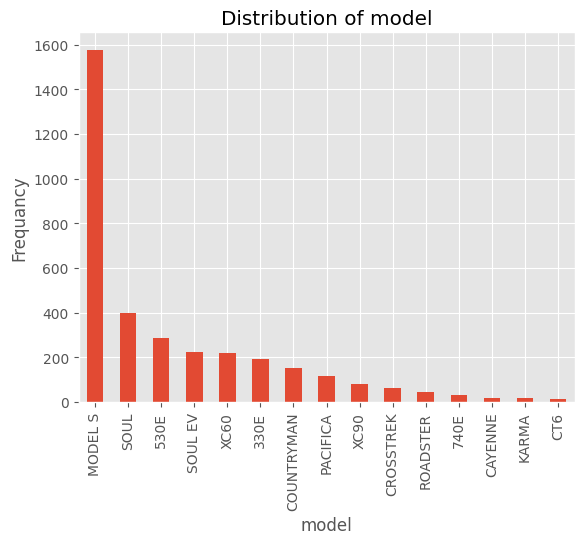

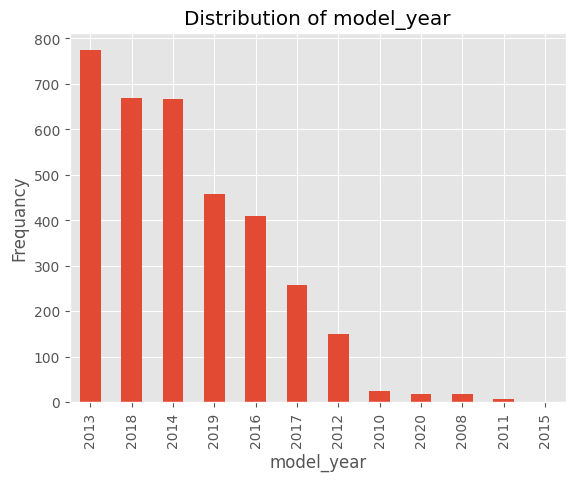

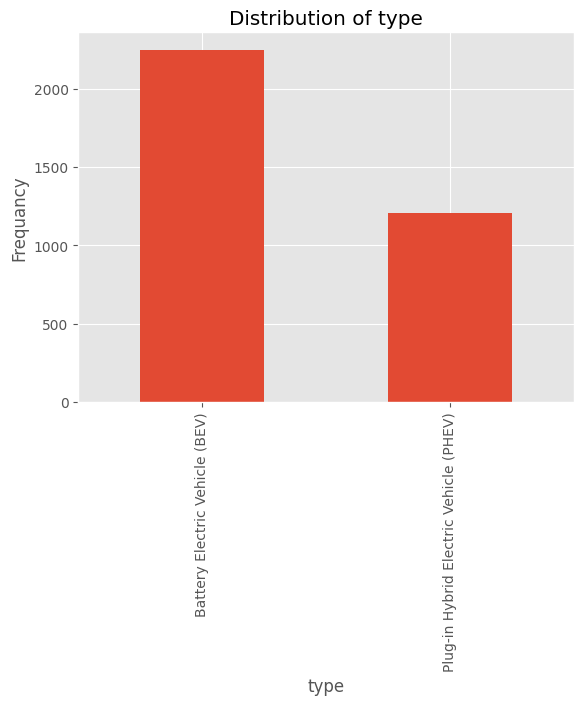

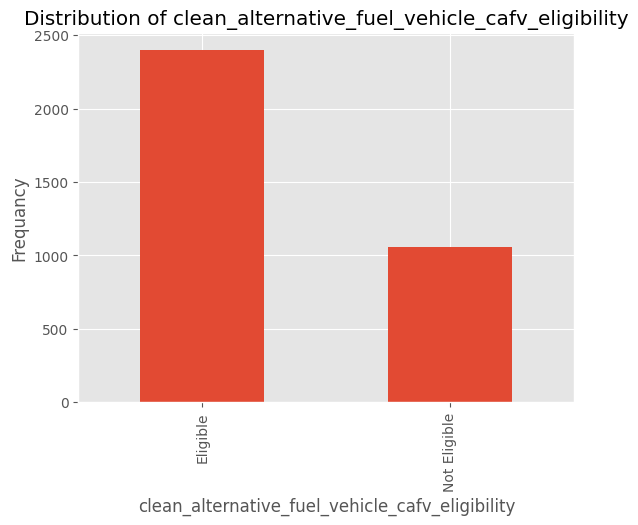

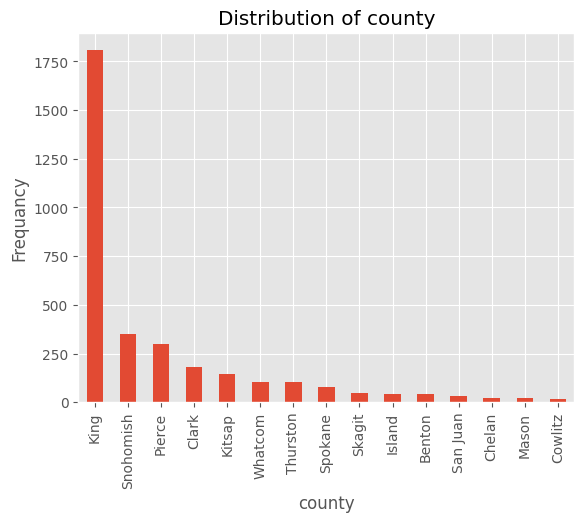

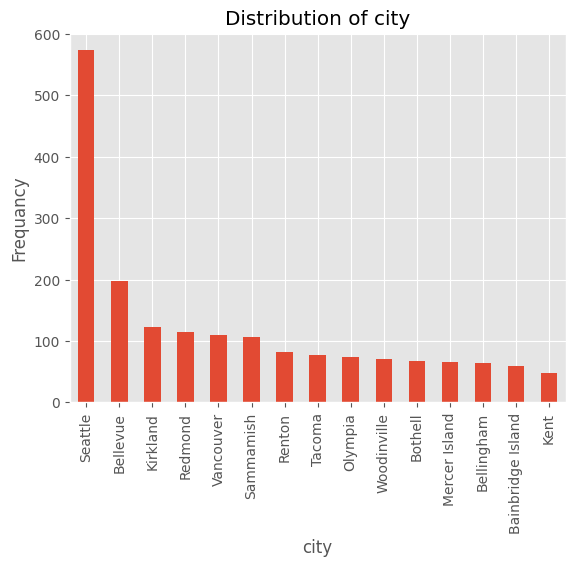

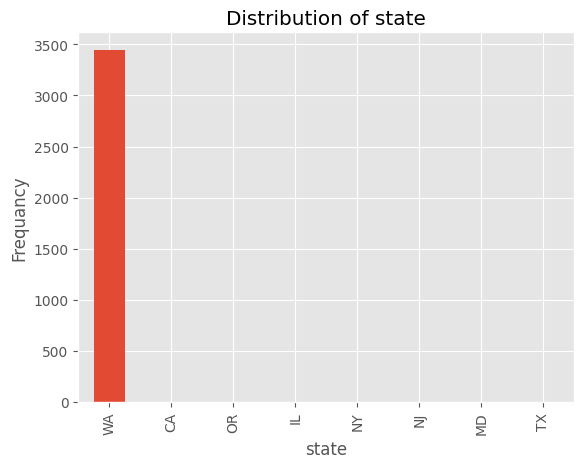

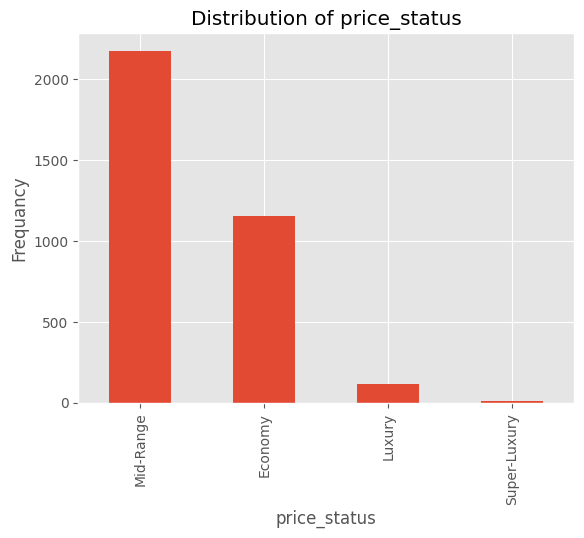

In [190]:
for column in ['company', 'model', 'model_year', 'type','clean_alternative_fuel_vehicle_cafv_eligibility','county','city', 'state', 'price_status']:
    ax=df[column].value_counts().head(15).plot(kind='bar',title=(f'Distribution of {column}'))
    ax.set_xlabel(f'{column}')
    ax.set_ylabel('Frequancy')
    plt.show()

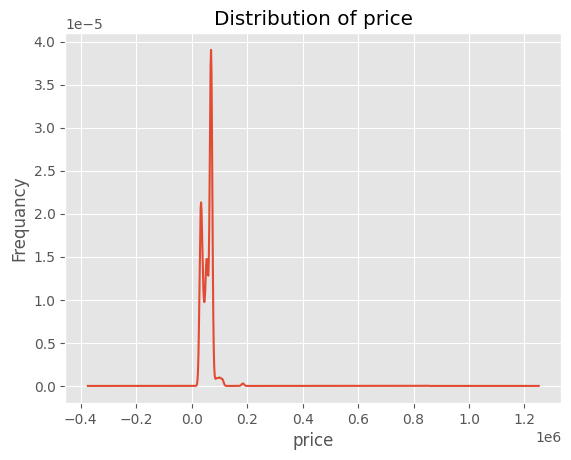

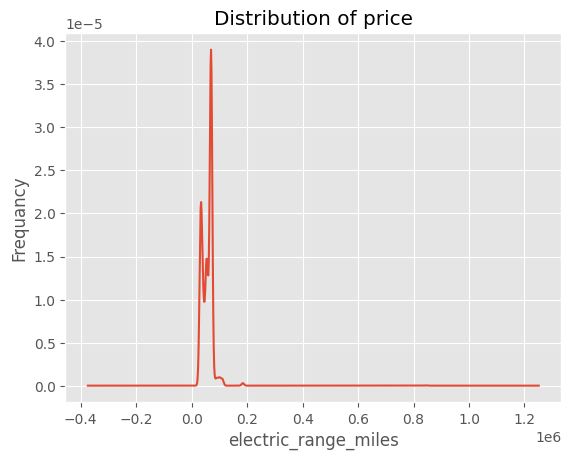

In [132]:

for column in ['price','electric_range_miles']:
       ax=df['price'].plot(kind='kde',title=('Distribution of price'))
       ax.set_xlabel(f'{column}')
       ax.set_ylabel('Frequancy')
       plt.show()

<m>

### 1.5 Import to sql-server

In [ ]:
server = r'DESKTOP-KHP38V4'
database = 'Electric_Vehicle'
driver = 'ODBC Driver 17 for SQL Server'
conn_str = (
    f"mssql+pyodbc://@{server}/{database}"
    f"?driver={driver.replace(' ', '+')}"
    "&trusted_connection=yes")
engine = create_engine(conn_str)
df_sql.to_sql('E-cars', engine, if_exists='replace', index=False)

In [ ]:
df_sql = df.copy()
df_sql.columns = [c.replace(" ", "_").replace("-", "_") for c in df_sql.columns]

<m>

## 2. Analyzing Data

<m>

### 2.1 Heatmap

<m>

In [133]:
numeric_columns=df.select_dtypes(include='number')

In [134]:
corr1=numeric_columns.corr()

In [135]:
corr1

,vehicle_id,model_year,electric_range_miles,price
vehicle_id,1.000000,0.243999,-0.223787,-0.125693
model_year,0.243999,1.000000,-0.930991,-0.469196
electric_range_miles,-0.223787,-0.930991,1.000000,0.407551
price,-0.125693,-0.469196,0.407551,1.000000


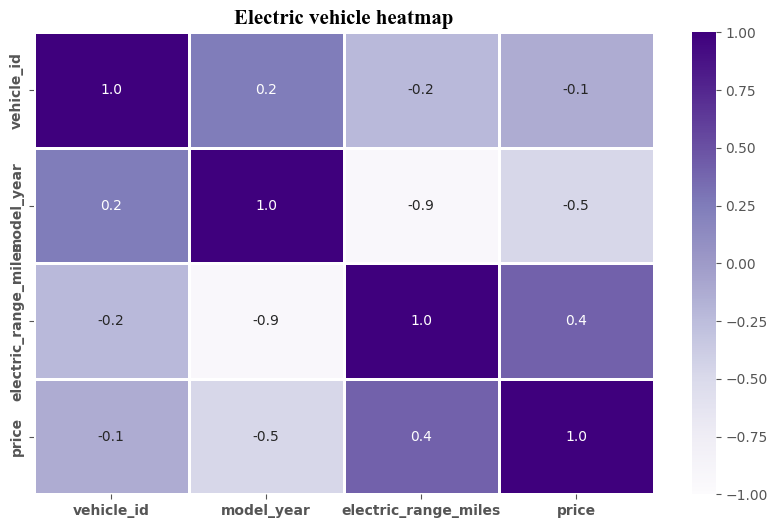

In [136]:
plt.figure(figsize=(10,6))
sns.heatmap(corr1,annot=True,vmax=1,vmin=-1,center=0,fmt='.1f',cmap='Purples',edgecolor='k',linewidth=1)
plt.title('Electric vehicle heatmap',fontfamily='times new roman',fontsize=15,fontweight='bold')
plt.xticks(fontsize=10,fontweight='bold')
plt.yticks(fontsize=10,fontweight='bold')
plt.show()

<m>

<M>

### 2.2 Counties with the most e-cars


<m>

In [137]:
Country_m=df.groupby('county').size().sort_values(ascending=False).head(10)
Country_m

county
King         1807
Snohomish     352
Pierce        299
Clark         182
Kitsap        143
Whatcom       106
Thurston      103
Spokane        78
Skagit         46
Island         42
dtype: int64

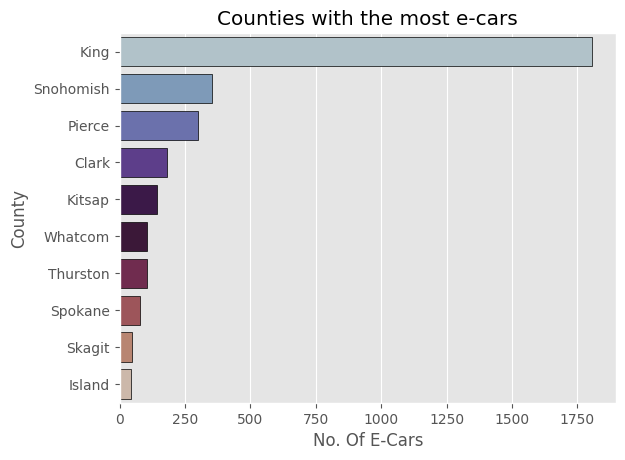

In [138]:
sns.barplot(x=Country_m.values,y=Country_m.index,edgecolor="k",palette='twilight')
plt.title('Counties with the most e-cars')
plt.xlabel("No. Of E-Cars")
plt.ylabel('County')
plt.show()


<m>

### 2.3 Counties that doesn't prefer e-cars

<m>

In [139]:
df.groupby("county").size().sort_values(ascending=True).head(18)

county
Burlington      1
Charles         1
Ulster          1
Columbia        1
Contra Costa    1
Rock Island     1
Riverside       1
Multnomah       1
Los Angeles     1
Williamson      1
Asotin          2
Whitman         2
Wahkiakum       2
Skamania        2
Lincoln         2
Klickitat       3
Stevens         3
Okanogan        4
dtype: int64

<m>

### 2.4 States e-cars population 

<m>

In [140]:
state_m=df.groupby("state").size().sort_values(ascending=False).head(10)
state_m

state
WA    3445
CA       3
IL       1
MD       1
NJ       1
NY       1
OR       1
TX       1
dtype: int64

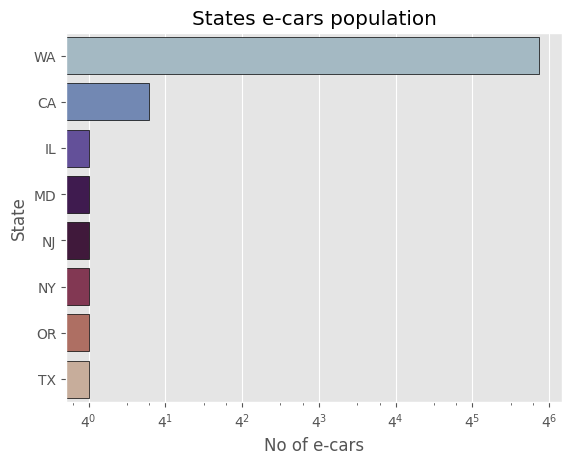

In [141]:
sns.barplot(x=state_m.values,y=state_m.index,edgecolor='k',palette='twilight')
plt.xscale('log', base=4)
plt.title('States e-cars population')
plt.xlabel("No of e-cars")
plt.ylabel('State')
plt.show()

<m>

### 2.5 Cities with the most e-cars

<m>

In [142]:
city_m=df.groupby("city").size().sort_values(ascending=False).head(10)
city_m

city
Seattle        573
Bellevue       198
Kirkland       123
Redmond        114
Vancouver      110
Sammamish      106
Renton          82
Tacoma          77
Olympia         74
Woodinville     70
dtype: int64

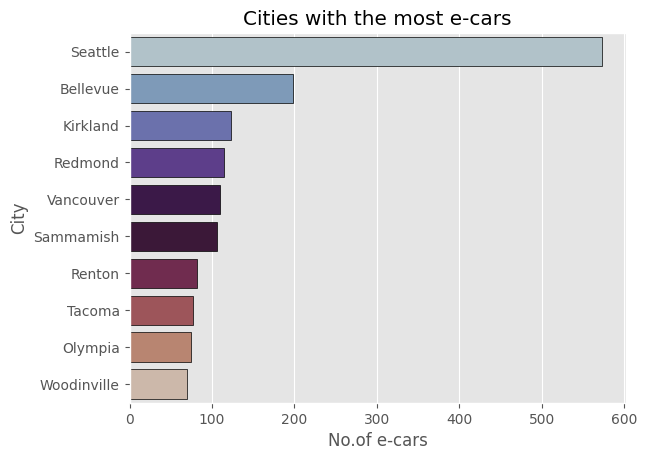

In [143]:
sns.barplot(x=city_m.values,y=city_m.index,edgecolor="k",palette='twilight')
plt.title('Cities with the most e-cars')
plt.xlabel("No.of e-cars")
plt.ylabel('City')
plt.show()

<m>

### 2.6 Cities that doesn't prefer e-cars

<m>

In [144]:
print(df.groupby("city").size().sort_values().head(100).to_string())

city
Zillah             1
Easton             1
Tokeland           1
Tonasket           1
Reardan            1
Touchet            1
Deming             1
Tenino             1
Dayton             1
Custer             1
Randle             1
Milton             1
Hoodsport          1
Montesano          1
Clarkston          1
Davenport          1
Rock Island        1
Surfside           1
Edwall             1
Indio              1
Snoqualmie Pass    1
Pittsburg          1
La Center          1
La Conner          1
Stevenson          1
Round Rock         1
Roslyn             1
Lilliwaup          1
Longbranch         1
Los Angeles        1
Lumberton          1
Lyle               1
Suquamish          1
Elma               1
Clallam Bay        1
Chewelah           1
Hughesville        1
Quincy             1
Peshastin          1
Pateros            1
Palouse            1
Ariel              1
Asotin             1
Baring             1
Oroville           1
Beaux Arts         1
Onalaska           1
Winthrop

<m>

### 2.7 Company with the most e-cars production

<m>

In [145]:
company_mp=df.groupby("company").size().sort_values(ascending=False).head(10)
company_mp

company
TESLA       1621
KIA          625
BMW          506
VOLVO        301
MINI         154
CHRYSLER     117
SUBARU        64
PORSCHE       31
FISKER        17
CADILLAC      15
dtype: int64

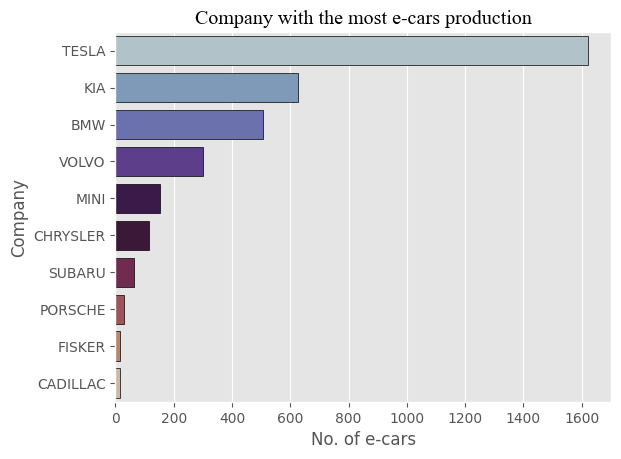

In [146]:
sns.barplot(x=company_mp.values,y=company_mp.index,edgecolor="k",palette='twilight')
plt.title("Company with the most e-cars production",fontfamily="times new roman")
plt.xlabel("No. of e-cars")
plt.ylabel('Company')
plt.show()

<m>

### 2.8 Company with the highest sales

<m>

In [147]:
company_s=df.groupby('company').price.sum().sort_values(ascending=False).head(10)
company_s

company
TESLA       113626550
BMW          26748400
KIA          20162350
VOLVO        16923050
MINI          5677300
CHRYSLER      4679415
PORSCHE       4414300
SUBARU        2239680
FISKER        1734000
CADILLAC      1126425
Name: price, dtype: int64

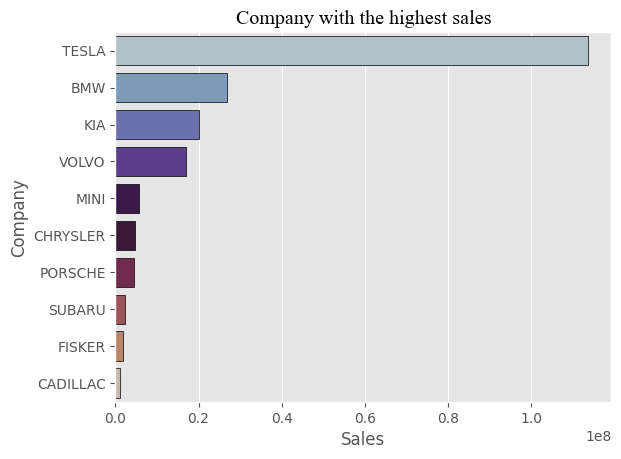

In [148]:
sns.barplot(x=company_s.values,y=company_s.index,edgecolor='k',palette='twilight')
plt.title('Company with the highest sales',fontfamily='times new roman')
plt.xlabel('Sales')
plt.ylabel('Company')
plt.show()

<m>

<m>

### 2.10 Company with the most expensive e-cars

<m>

In [149]:
company_high_p=df.groupby('company').price.max().sort_values(ascending=False).head(10)
company_high_p

company
PORSCHE     845000
TESLA       110950
FISKER      102000
BMW          91250
CADILLAC     75095
VOLVO        64950
CHRYSLER     39995
MINI         36900
SUBARU       34995
KIA          33950
Name: price, dtype: int64

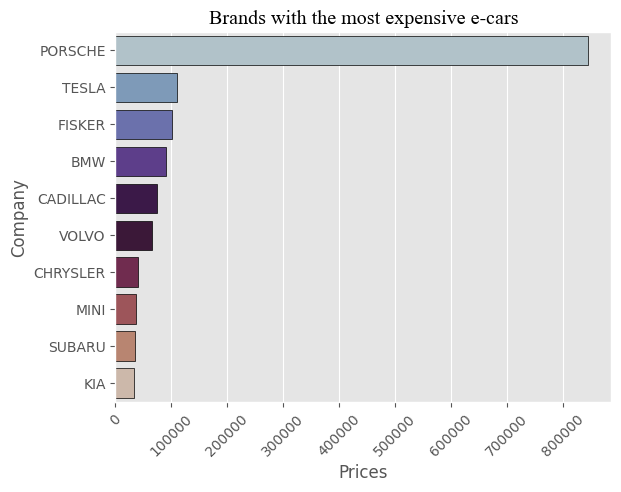

In [150]:
sns.barplot(x=company_high_p.values,y=company_high_p.index,edgecolor="k",palette='twilight')
plt.title("Brands with the most expensive e-cars",fontfamily="times new roman")
plt.xlabel("Prices")
plt.ylabel('Company')
plt.xticks(rotation=45)
plt.show()

<M>

### 2.11 Models with the highest sales 

<m>

In [151]:
Model_s=df.groupby('model').price.sum().sort_values(ascending=False).head(10)
Model_s

model
MODEL S       108752500
530E           15489150
SOUL           12748050
XC60           11532200
330E            8545100
SOUL EV         7414300
COUNTRYMAN      5677300
XC90            5390850
ROADSTER        4874050
PACIFICA        4679415
Name: price, dtype: int64

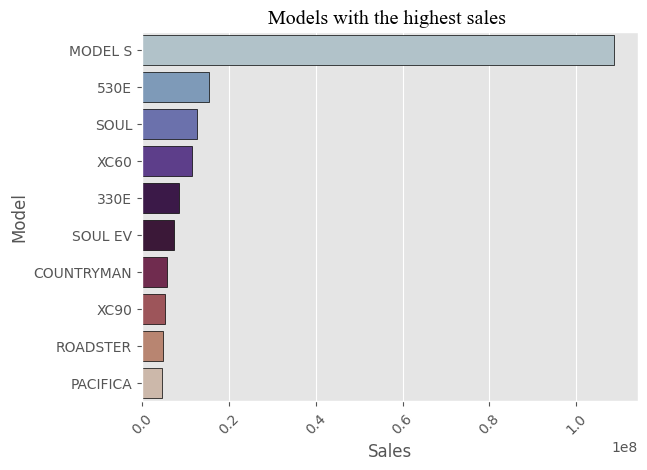

In [152]:
sns.barplot(x=Model_s.values,y=Model_s.index,edgecolor="k",palette='twilight')
plt.title("Models with the highest sales ",fontfamily="times new roman")
plt.xlabel("Sales")
plt.ylabel('Model')
plt.xticks(rotation=45)
plt.show()

<m>

### 2.12 Models with the lowest sales 

<m>

In [153]:
Model_sl=df.groupby('model').price.sum().sort_values(ascending=True).head(10)
Model_sl

model
WHEEGO         98985
918           845000
CT6          1126425
CAYENNE      1540900
KARMA        1734000
PANAMERA     2028400
CROSSTREK    2239680
740E         2714150
PACIFICA     4679415
ROADSTER     4874050
Name: price, dtype: int64

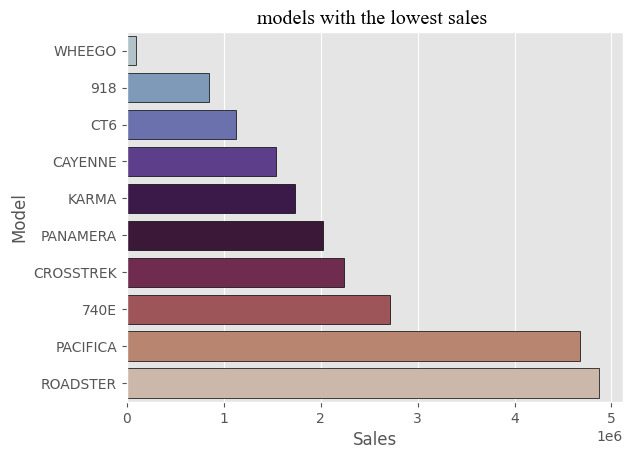

In [154]:
sns.barplot(x=Model_sl.values,y=Model_sl.index,edgecolor="k",palette='twilight')
plt.title("models with the lowest sales ",fontfamily="times new roman")
plt.xlabel("Sales")
plt.ylabel('Model')
plt.show()

<m>

### 2.13 Most expinsive e-cars models

<m>

In [155]:
Model_e=df.groupby('model').price.max().sort_values(ascending=False).head(10)
Model_e

model
918         845000
PANAMERA    184400
ROADSTER    110950
KARMA       102000
740E         91250
CAYENNE      81100
CT6          75095
MODEL S      69900
XC90         64950
530E         55700
Name: price, dtype: int64

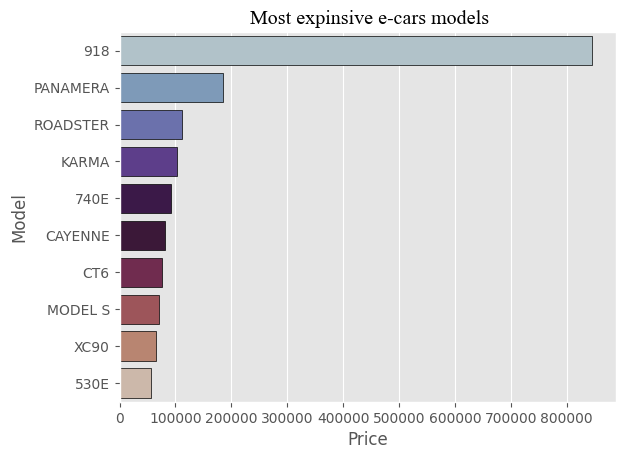

In [156]:
sns.barplot(x=Model_e.values,y=Model_e.index,edgecolor="k",palette='twilight')
plt.title(" Most expinsive e-cars models",fontfamily="times new roman")
plt.xlabel("Price")
plt.ylabel('Model')
plt.show()

<m>

### 2.14 Cheapiest e-cars models

<m>

In [157]:
Model_c=df.groupby('model').price.max().sort_values(ascending=True).head(10)
Model_c

model
SOUL          31950
WHEEGO        32995
SOUL EV       33950
CROSSTREK     34995
COUNTRYMAN    36900
PACIFICA      39995
330E          45600
XC60          52900
530E          55700
XC90          64950
Name: price, dtype: int64

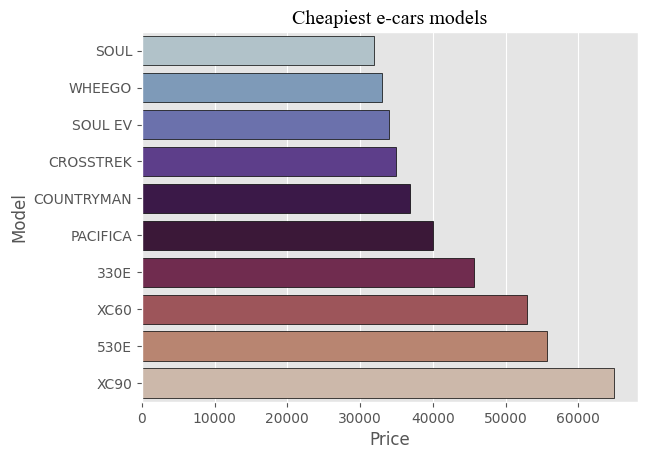

In [158]:
sns.barplot(x=Model_c.values,y=Model_c.index,edgecolor="k",palette='twilight')
plt.title("Cheapiest e-cars models",fontfamily="times new roman")
plt.xlabel("Price")
plt.ylabel('Model')
plt.show()

<m>

### 2.15 Most powerfule e-cars

<m>

In [159]:
model_p=df.groupby('model')['electric_range_miles'].max().sort_values(ascending=False).head(10)
model_p

model
MODEL S      265
ROADSTER     245
SOUL EV      111
WHEEGO       100
SOUL          93
KARMA         33
PACIFICA      32
CT6           31
XC90          19
CROSSTREK     17
Name: electric_range_miles, dtype: int64

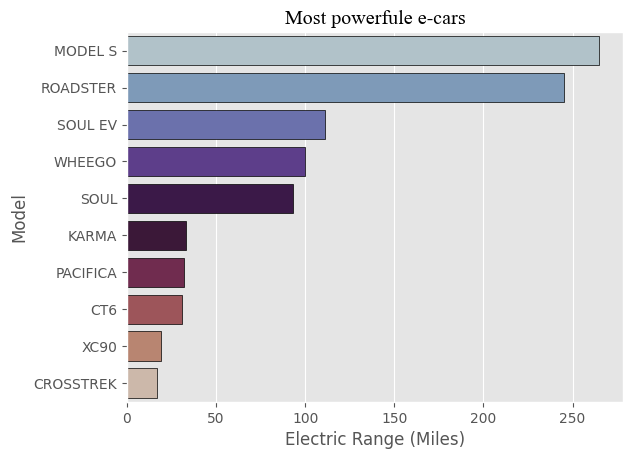

In [160]:
sns.barplot(x=model_p.values,y=model_p.index,edgecolor="k",palette='twilight')
plt.title("Most powerfule e-cars",fontfamily="times new roman")
plt.xlabel("Electric Range (Miles)")
plt.ylabel('Model')
plt.show()

<m>

### 2.16 Least powerful e-cars

<m>

In [161]:
model_pl=df.groupby('model')['electric_range_miles'].max().sort_values(ascending=True).head(9)
model_pl

model
918           12
COUNTRYMAN    12
330E          14
740E          14
CAYENNE       14
PANAMERA      14
530E          16
CROSSTREK     17
XC60          17
Name: electric_range_miles, dtype: int64

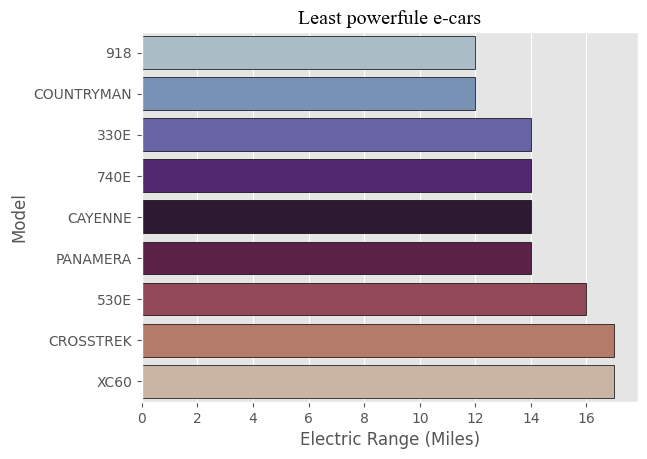

In [162]:
sns.barplot(x=model_pl.values,y=model_pl.index,edgecolor="k",palette='twilight')
plt.title("Least powerfule e-cars",fontfamily="times new roman")
plt.xlabel("Electric Range (Miles)")
plt.ylabel('Model')
plt.show()

<m>

### 2.17 Type analysis

<m>

In [163]:
type_n=df.groupby('type').vin.count().sort_values(ascending=False)
type_p=df.groupby('type').price.sum().sort_values(ascending=False)
type_pow=df.groupby('type')['electric_range_miles'].sum().sort_values(ascending=False)

In [164]:
type_n

type
Battery Electric Vehicle (BEV)            2246
Plug-in Hybrid Electric Vehicle (PHEV)    1208
Name: vin, dtype: int64

In [165]:
type_p

type
Battery Electric Vehicle (BEV)            133788900
Plug-in Hybrid Electric Vehicle (PHEV)     63641555
Name: price, dtype: int64

In [166]:
type_pow

type
Battery Electric Vehicle (BEV)            405515
Plug-in Hybrid Electric Vehicle (PHEV)     21059
Name: electric_range_miles, dtype: int64

In [167]:
summary_df=pd.concat([type_p,type_pow,type_n],axis=1).reset_index().rename(columns={'index':'type'})
melted_df=summary_df.melt(id_vars='type',value_vars=['price','electric_range_miles','vin'],var_name='Metric',value_name='value')

In [168]:
summary_df

,type,price,electric_range_miles,vin
0,Battery Electric Vehicle (BEV),133788900,405515,2246
1,Plug-in Hybrid Electric Vehicle (PHEV),63641555,21059,1208


In [169]:
melted_df

,type,Metric,value
0,Battery Electric Vehicle (BEV),price,133788900
1,Plug-in Hybrid Electric Vehicle (PHEV),price,63641555
2,Battery Electric Vehicle (BEV),electric_range_miles,405515
3,Plug-in Hybrid Electric Vehicle (PHEV),electric_range_miles,21059
4,Battery Electric Vehicle (BEV),vin,2246
5,Plug-in Hybrid Electric Vehicle (PHEV),vin,1208


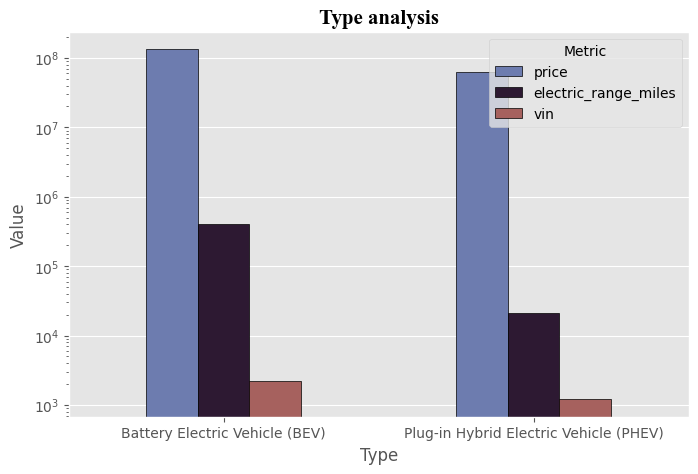

In [170]:
plt.figure(figsize=(8,5))
sns.barplot(x="type",y="value",hue="Metric",data=melted_df,edgecolor="k", palette="twilight",width=0.5)
plt.yscale('log')
plt.title("Type analysis",fontfamily="times new roman",fontsize=15,fontweight="bold")
plt.xlabel("Type")
plt.ylabel("Value")
plt.show()

<m>

### 2.18 CAFV analysis

<m>

In [171]:
df.columns

Index(['vin', 'vehicle_id', 'company', 'model', 'model_year',
       'electric_range_miles', 'type',
       'clean_alternative_fuel_vehicle_cafv_eligibility', 'price', 'county',
       'city', 'state', 'price_status'],
      dtype='str')

In [172]:
cafv_n=df.groupby("clean_alternative_fuel_vehicle_cafv_eligibility").vin.count().sort_values(ascending=False)
cafv_p=df.groupby('clean_alternative_fuel_vehicle_cafv_eligibility').price.sum().sort_values(ascending=False)
cafv_pow=df.groupby('clean_alternative_fuel_vehicle_cafv_eligibility')['electric_range_miles'].sum().sort_values(ascending=False)

In [173]:
cafv_n

clean_alternative_fuel_vehicle_cafv_eligibility
Eligible        2398
Not Eligible    1056
Name: vin, dtype: int64

In [174]:
cafv_p

clean_alternative_fuel_vehicle_cafv_eligibility
Eligible        141427725
Not Eligible     56002730
Name: price, dtype: int64

In [175]:
cafv_pow

clean_alternative_fuel_vehicle_cafv_eligibility
Eligible        410585
Not Eligible     15989
Name: electric_range_miles, dtype: int64

In [176]:
summary_df=pd.concat([cafv_p,cafv_pow,cafv_n],axis=1).reset_index().rename(columns={'index':'clean_alternative_fuel_vehicle_cafv_eligibility'})
melted_df=summary_df.melt(id_vars='clean_alternative_fuel_vehicle_cafv_eligibility',value_vars=['price','electric_range_miles','vin'],var_name='Metric',value_name='Value')

In [177]:
summary_df

,clean_alternative_fuel_vehicle_cafv_eligibility,price,electric_range_miles,vin
0,Eligible,141427725,410585,2398
1,Not Eligible,56002730,15989,1056


In [178]:
melted_df

,clean_alternative_fuel_vehicle_cafv_eligibility,Metric,Value
0,Eligible,price,141427725
1,Not Eligible,price,56002730
2,Eligible,electric_range_miles,410585
3,Not Eligible,electric_range_miles,15989
4,Eligible,vin,2398
5,Not Eligible,vin,1056


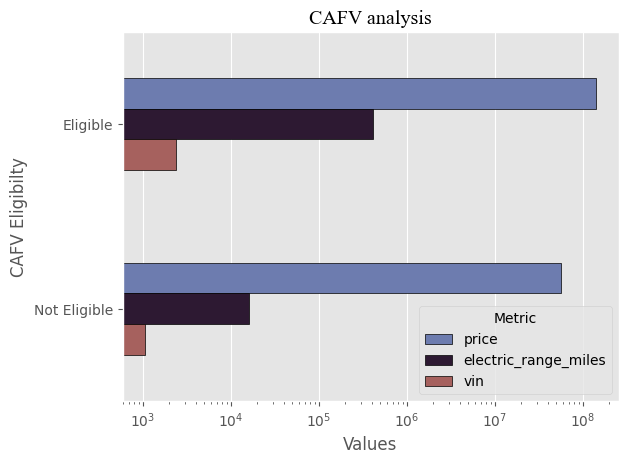

In [179]:
sns.barplot(x='Value',y='clean_alternative_fuel_vehicle_cafv_eligibility',hue='Metric',data=melted_df,width=0.5,edgecolor='k',palette="twilight")
plt.title('CAFV analysis',fontfamily='times new roman')
plt.xlabel('Values')
plt.ylabel('CAFV Eligibilty')
plt.xscale('log')
plt.show()

<m>

### 2.19 Price status analysis

<m>

In [180]:
ps_n=df.groupby('price_status').vin.count().sort_values(ascending=False)
ps_p=df.groupby('price_status').price.sum().sort_values(ascending=False)
ps_pow=df.groupby('price_status')['electric_range_miles'].sum().sort_values(ascending=False)

In [181]:
ps_n

price_status
Mid-Range       2176
Economy         1154
Luxury           112
Super-Luxury      12
Name: vin, dtype: int64

In [182]:
ps_p

price_status
Mid-Range       142291125
Economy          41402830
Luxury           10863100
Super-Luxury      2873400
Name: price, dtype: int64

In [183]:
ps_pow

price_status
Mid-Range       345230
Economy          69111
Luxury           12067
Super-Luxury       166
Name: electric_range_miles, dtype: int64

In [184]:
summary_df=pd.concat([ps_p,ps_pow,ps_n],axis=1).reset_index().rename(columns={'index':'price_status'})
melted_df=summary_df.melt(id_vars='price_status',value_vars=['price','electric_range_miles','vin'],var_name='Metric',value_name='Value')

In [185]:
summary_df

,price_status,price,electric_range_miles,vin
0,Mid-Range,142291125,345230,2176
1,Economy,41402830,69111,1154
2,Luxury,10863100,12067,112
3,Super-Luxury,2873400,166,12


In [186]:
melted_df

,price_status,Metric,Value
0,Mid-Range,price,142291125
1,Economy,price,41402830
2,Luxury,price,10863100
3,Super-Luxury,price,2873400
4,Mid-Range,electric_range_miles,345230
5,Economy,electric_range_miles,69111
6,Luxury,electric_range_miles,12067
7,Super-Luxury,electric_range_miles,166
8,Mid-Range,vin,2176
9,Economy,vin,1154


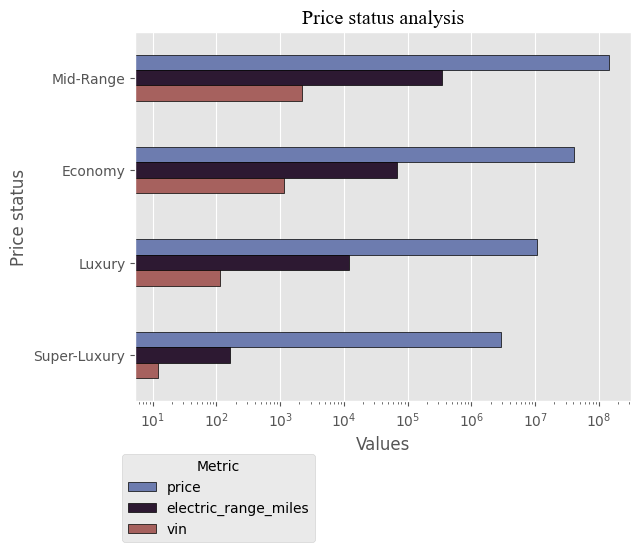

In [187]:
sns.barplot(x='Value',y='price_status',hue='Metric',data=melted_df,width=0.5,edgecolor='k',palette="twilight")
plt.title('Price status analysis',fontfamily='times new roman')
plt.xlabel('Values')
plt.ylabel('Price status')
plt.xscale('log')
plt.legend(
title="Metric",               
loc="lower left",             
bbox_to_anchor=(-0.04, -0.4),  
ncol=1,                      
frameon=True                   
)
plt.show()

<m>

### 2.20 Sales analysis

<m>

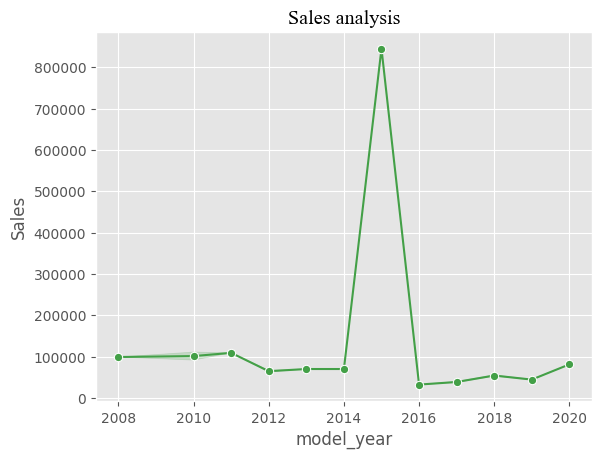

In [188]:
sns.lineplot(x='model_year',y='price',data=df,color='#43A047',marker='o')
plt.title('Sales analysis',fontfamily='times new roman')
plt.ylabel('Sales')
plt.show()

<m>

### 2.21 Relation between power and price

<m>

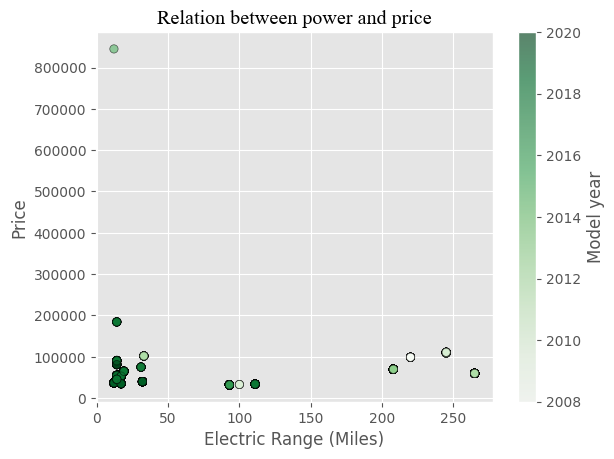

In [189]:
plt.scatter(df['electric_range_miles'],df['price'],edgecolor='k',cmap='Greens',c=df['model_year'],alpha=0.6)
plt.title('Relation between power and price',fontfamily='times new roman')
plt.xlabel('Electric Range (Miles)')
plt.ylabel('Price')
plt.colorbar(label='Model year')
plt.show()